# Modelos Avanzados — XGBoost y Ridge Regression

## Objetivo de este notebook

Explorar modelos más complejos para intentar superar el baseline de Regresión Lineal
(RMSE log = 0.1317) establecido en el Notebook 04.

**Modelos evaluados:**
1. **XGBoost** con parámetros base (punto de partida)
2. **XGBoost optimizado** con GridSearchCV (27 combinaciones, cv=5)
3. **Ridge Regression** con RidgeCV (regularización L2, 6 alphas candidatos)

**Hipótesis:** XGBoost podría capturar relaciones no lineales en el segmento premium
donde el baseline lineal muestra mayor error.

**Input:** `data/train_features.csv` (mismo split que Notebook 04: `random_state=42`)

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path

# Modelos y optimización
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor  # Gradient Boosting — modelo principal candidato

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Crea la carpeta images/ en la raíz del proyecto si no existe
Path('../../images').mkdir(exist_ok=True)

In [2]:
data_path = Path('../../data/train_features.csv')
# keep_default_na=False desactiva la interpretación automática de nulos
# na_values=[] lista vacía — ningún valor adicional se interpreta como nulo
df = pd.read_csv(data_path, keep_default_na=False, na_values=[''])

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
df.columns

Filas: 1460
Columnas: 47
Nulos totales: 0


Index(['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath',
       'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF',
       '2ndFlrSF', 'OpenPorchSF', 'HalfBath', 'property_age',
       'year_since_remod', 'ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC',
       'BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'PavedDrive',
       'LotShape', 'Foundation_CBlock', 'Foundation_PConc', 'Foundation_Slab',
       'Foundation_Stone', 'Foundation_Wood', 'GarageType_Attchd',
       'GarageType_Basment', 'GarageType_BuiltIn', 'GarageType_CarPort',
       'GarageType_Detchd', 'GarageType_None', 'MSZoning_FV', 'MSZoning_RH',
       'MSZoning_RL', 'MSZoning_RM', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial', 'CentralAir', 'Neighborhood', 'SalePrice_log'],
      dtype='str')

### Modelo 1: XGBoost - Parámetros Base

Se entrenó un modelo XGBoost con parámetros iniciales como punto de partida
para establecer una referencia antes de la optimización.

**Parámetros utilizados:**
- n_estimators: 500
- max_depth: 4
- learning_rate: 0.05
- random_state: 42

In [3]:
X = df.drop('SalePrice_log', axis=1)
y = df['SalePrice_log']

print(f'Shape X: {X.shape}')
print(f'Shape Y: {y.shape}')

# random_state=42 garantiza que el split sea idéntico al del Notebook 04 — comparación justa entre modelos
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Data Set: {x_train.shape[0]} filas")
print(f"Test Data Set: {x_test.shape[0]} filas")

# XGBoost con parámetros base como punto de partida antes del tuning
# max_depth=3: árboles poco profundos reducen overfitting en datasets medianos
# learning_rate=0.05: aprendizaje conservador — requiere más árboles pero generaliza mejor
# n_estimators=500: suficientes iteraciones para que learning_rate bajo converja
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_xgb.fit(x_train, y_train)
y_pred_log = model_xgb.predict(x_test)

# Métricas en escala logarítmica (métrica oficial Kaggle)
mae_log  = mean_absolute_error(y_test, y_pred_log)
mse_log  = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log   = r2_score(y_test, y_pred_log)

print(f"MAE (log): {mae_log:.4f}")
print(f"MSE (log): {mse_log:.4f}")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"R² (log): {r2_log:.4f}")

# Reconversión a USD para interpretación de negocio — inversa de np.log() es np.exp()
y_pred_usd = np.exp(y_pred_log)
y_test_usd = np.exp(y_test)

mae_usd  = mean_absolute_error(y_test_usd, y_pred_usd)
mse_usd  = mean_squared_error(y_test_usd, y_pred_usd)
rmse_usd = np.sqrt(mse_usd)
r2_usd   = r2_score(y_test_usd, y_pred_usd)

print(f"MAE (USD): ${mae_usd:,.0f}")
print(f"RMSE (USD): ${rmse_usd:,.0f}")
print(f"R² (USD): {r2_usd:.4f}")

Shape X: (1460, 46)
Shape Y: (1460,)
Training Data Set: 1168 filas
Test Data Set: 292 filas


MAE (log): 0.0928
MSE (log): 0.0201
RMSE (log): 0.1416
R² (log): 0.8925
MAE (USD): $16,033
RMSE (USD): $26,153
R² (USD): 0.9108


**Resultados:**
| Métrica | Valor |
|---------|-------|
| RMSE (log) | 0.1416 |
| RMSE (USD) | $26,153 |
| R² (USD) | 0.9108 |
| MAE (USD) | $16,033 |

**Conclusión:**
El XGBoost optimizado superó levemente al baseline en USD ($26,153 vs $26,361)
y mejoró el R². Sin embargo, en escala logarítmica (métrica oficial de Kaggle)
el baseline lineal sigue siendo superior (0.1317 vs 0.1416).
El max_depth óptimo de 3 indica que árboles poco profundos generalizan mejor
con este dataset, reduciendo el riesgo de overfitting.

### Modelo 2: XGBoost - Optimizado con GridSearchCV

Se aplicó GridSearchCV para encontrar la combinación óptima de hiperparámetros.
El proceso evaluó 27 combinaciones con cv=5, totalizando 135 entrenamientos.

**Grid de búsqueda:**
| Hiperparámetro | Valores explorados |
|----------------|-------------------|
| n_estimators | 100, 300, 500 |
| max_depth | 3, 4, 5 |
| learning_rate | 0.01, 0.05, 0.1 |

**Mejores parámetros encontrados:**
- n_estimators: 500
- max_depth: 3
- learning_rate: 0.05

In [4]:
# Grid de búsqueda: 3×3×3 = 27 combinaciones × cv=5 = 135 entrenamientos en total
params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# scoring='neg_mean_squared_error': GridSearchCV minimiza MSE (negativo porque maximiza por defecto)
# n_jobs=2: usa 2 núcleos en paralelo — evita congelar el sistema usando todos los recursos
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=2,
    verbose=1
)

grid_search.fit(x_train, y_train)

# best_params_: diccionario con la combinación óptima
# best_score_: MSE negativo del mejor modelo en cv — aplicamos raíz y negación para obtener RMSE
print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor RMSE (log, cv): {np.sqrt(-grid_search.best_score_):.4f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
Mejor RMSE (log, cv): 0.1353


### Modelo 3: Ridge Regression con RidgeCV

Se exploró Ridge Regression como alternativa al XGBoost. Ridge aplica
regularización L2 penalizando coeficientes grandes para mejorar la
generalización del modelo.

**Configuración:**
- Alphas explorados: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
- cv: 5

**Mejor alpha encontrado:** 10.0


In [5]:
# RidgeCV prueba múltiples alphas con cross-validation interno y selecciona el mejor
# Alpha controla la regularización L2: mayor alpha → coeficientes más pequeños → menos varianza, más sesgo
ridge_cv = RidgeCV(
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    cv=5
)

ridge_cv.fit(x_train, y_train)
print(f'Mejor alpha: {ridge_cv.alpha_}')  # Alpha óptimo encontrado por CV

y_pred_log_ridge = ridge_cv.predict(x_test)
y_pred_ridge_usd = np.exp(y_pred_log_ridge)  # Reconversión a USD

# Métricas en escala logarítmica
mae_ridge_log  = mean_absolute_error(y_test, y_pred_log_ridge)
rmse_ridge_log = np.sqrt(mean_squared_error(y_test, y_pred_log_ridge))
r2_ridge_log   = r2_score(y_test, y_pred_log_ridge)
print(f"MAE Ridge (log): {mae_ridge_log:.4f}")
print(f"RMSE Ridge (log): {rmse_ridge_log:.4f}")
print(f"R² Ridge (log): {r2_ridge_log:.4f}")

# Métricas en USD
mae_ridge_usd  = mean_absolute_error(y_test_usd, y_pred_ridge_usd)
rmse_ridge_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_ridge_usd))
r2_ridge_usd   = r2_score(y_test_usd, y_pred_ridge_usd)
print(f"MAE Ridge (USD): ${mae_ridge_usd:,.0f}")
print(f"RMSE Ridge (USD): ${rmse_ridge_usd:,.0f}")
print(f"R² Ridge (USD): {r2_ridge_usd:.4f}")

Mejor alpha: 10.0
MAE Ridge (log): 0.0987
RMSE Ridge (log): 0.1395
R² Ridge (log): 0.8957
MAE Ridge (USD): $17,166
RMSE Ridge (USD): $26,424
R² Ridge (USD): 0.9090


**Resultados:**
| Métrica | Valor |
|---------|-------|
| RMSE (log) | 0.1395 |
| RMSE (USD) | $26,424 |
| R² (USD) | 0.9090 |
| MAE (USD) | $17,166 |

**Conclusión:**
El alpha óptimo de 10.0 indica que el dataset requiere una penalización
considerable, confirmando la presencia de coeficientes grandes que
afectaban al modelo lineal simple. Ridge mejora al XGBoost en RMSE log
pero no supera al baseline lineal.

### Comparación Final de Modelos

| Modelo | RMSE (log) | RMSE (USD) | R² (USD) |
|--------|-----------|------------|---------|
| Baseline Lineal | **0.1317** | $26,361 | 0.909 |
| XGBoost Optimizado | 0.1416 | **$26,153** | **0.911** |
| Ridge (α=10) | 0.1395 | $26,424 | 0.909 |
| Benchmark Kaggle | 0.1358 | - | - |

**Modelo seleccionado para submit:** Baseline Lineal
El modelo de regresión lineal obtiene el mejor RMSE en escala logarítmica,
que es la métrica oficial de Kaggle. Su simplicidad y estabilidad lo hacen
la opción más confiable para la predicción final.

---

## Conclusiones — Modelos Avanzados

### Comparación final

| Modelo | RMSE (log) ↓ | RMSE (USD) ↓ | R² ↑ | Ganador |
|--------|-------------|-------------|------|---------|
| **Baseline Lineal** | **0.1317** | $26,361 | 0.909 | ✅ Kaggle |
| XGBoost Optimizado | 0.1416 | **$26,153** | **0.911** | ✅ USD |
| Ridge (α=10) | 0.1395 | $26,424 | 0.909 | — |
| Benchmark Kaggle | 0.1358 | — | — | Referencia |

### Análisis por modelo

**XGBoost:** El `max_depth=3` óptimo indica que los árboles poco profundos generalizan mejor
en este dataset. A pesar de 27 combinaciones de hiperparámetros evaluadas, no supera al baseline
en RMSE log — evidencia de que las relaciones lineales dominan en este conjunto de variables.

**Ridge:** El `alpha=10` confirma que el modelo lineal simple tiene coeficientes con alta
varianza que la regularización L2 estabiliza. Mejora sobre XGBoost en RMSE log pero no sobre el baseline.

**Baseline Lineal:** Gana en la métrica oficial de Kaggle (RMSE log) y es el más interpretable.
Su simplicidad no es una debilidad — es la elección correcta dado el dataset.

### Modelo seleccionado
**Regresión Lineal (Baseline)** — mejor RMSE en escala logarítmica (métrica Kaggle),
cumple todos los supuestos estadísticos y su comportamiento es interpretable mediante coeficientes y SHAP Values.

### Próximo paso
**Notebook 06** — Análisis de importancia de variables mediante coeficientes y SHAP Values.

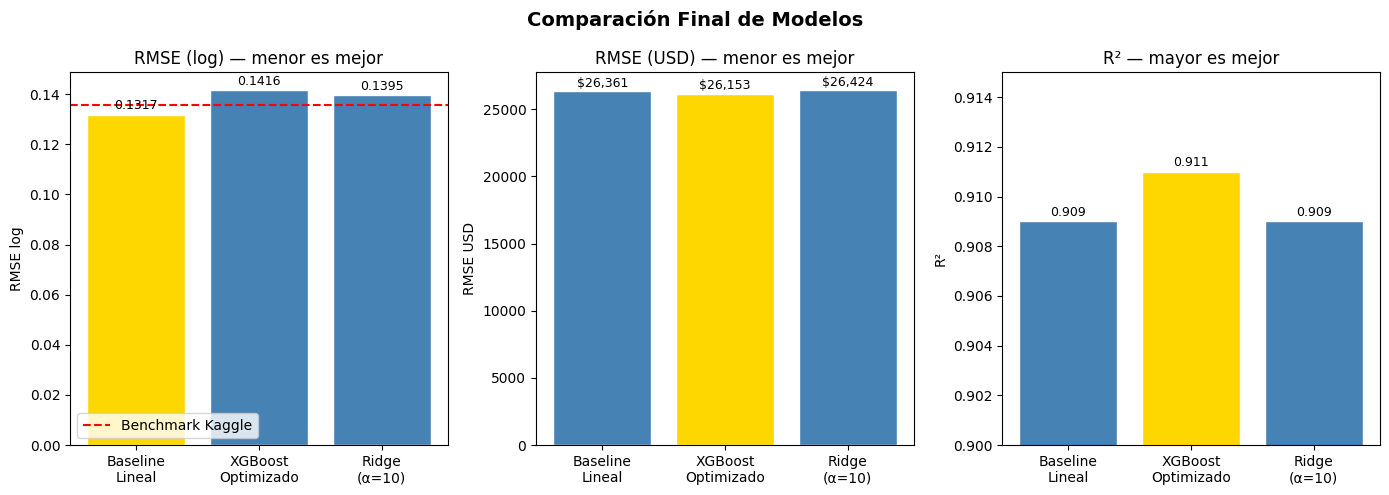

In [6]:
# ============================================================
# VISUALIZACIÓN — COMPARACIÓN FINAL DE MODELOS
# ============================================================
# Recopilamos las métricas de los tres modelos para comparar visualmente
modelos = ['Baseline\nLineal', 'XGBoost\nOptimizado', 'Ridge\n(α=10)']
rmse_log_vals = [0.1317, 0.1416, 0.1395]
rmse_usd_vals = [26361, 26153, 26424]
r2_vals       = [0.909, 0.911, 0.909]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- RMSE log: métrica oficial Kaggle — menor es mejor ---
colors_log = ['gold' if v == min(rmse_log_vals) else 'steelblue' for v in rmse_log_vals]
bars0 = axes[0].bar(modelos, rmse_log_vals, color=colors_log, edgecolor='white')
axes[0].axhline(y=0.1358, color='red', linestyle='--', linewidth=1.5, label='Benchmark Kaggle')
axes[0].set_title('RMSE (log) — menor es mejor')
axes[0].set_ylabel('RMSE log')
axes[0].legend()
for bar, val in zip(bars0, rmse_log_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# --- RMSE USD: perspectiva de negocio — menor es mejor ---
colors_usd = ['gold' if v == min(rmse_usd_vals) else 'steelblue' for v in rmse_usd_vals]
bars1 = axes[1].bar(modelos, rmse_usd_vals, color=colors_usd, edgecolor='white')
axes[1].set_title('RMSE (USD) — menor es mejor')
axes[1].set_ylabel('RMSE USD')
for bar, val in zip(bars1, rmse_usd_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# --- R²: mayor es mejor ---
colors_r2 = ['gold' if v == max(r2_vals) else 'steelblue' for v in r2_vals]
bars2 = axes[2].bar(modelos, r2_vals, color=colors_r2, edgecolor='white')
axes[2].set_title('R² — mayor es mejor')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0.90, 0.915)
for bar, val in zip(bars2, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación Final de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../images/05_comparacion_modelos.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()